<a href="https://colab.research.google.com/github/macarenahulsken/connectatel-data-analysis/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Objetivo: evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

---
## 🧩 Paso 1: Cargar y explorar

**familiarización con la estructura de los tres datasets**.  

### 1.1 Carga de datos y vista rápida

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [50]:
# cargar archivos
plans = pd.read_csv('/content/plans.csv')
users = pd.read_csv('/content/users_latam.csv')
usage = pd.read_csv('/content/usage.csv')

In [51]:
plans.sample(2)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
1,Premium,500,20,600,25,1.0,0.05,0.07
0,Basico,100,5,100,12,1.2,0.08,0.10


In [52]:
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
2146,12146,Mariana,Garcia,55,Medellín,2023-08-11 14:44:44.471117784,Premium,NaN
24,10024,Mariana,Gomez,42,MTY,2022-01-07 13:43:09.947486871,Basico,NaN
3427,13427,Mateo,Ramirez,44,CDMX,2024-07-27 09:01:12.918229568,Basico,NaN
3987,13987,Mateo,Ramirez,67,Cali,2024-12-27 17:08:25.026256576,Basico,NaN
426,10426,Luis,Gomez,56,CDMX,2022-04-27 15:31:11.567891974,Basico,NaN


In [53]:
usage.sample(5)

,id,user_id,type,date,duration,length
29597,29598,13282,text,2024-05-13 22:18:52.408310206,NaN,61.0
6554,6555,11237,call,2024-01-30 15:46:55.900397509,3.05,NaN
1252,1253,10548,call,2024-01-06 15:58:14.157353933,0.51,NaN
30174,30175,10790,text,2024-05-16 12:58:41.968049200,NaN,45.0
35569,35570,12317,text,2024-06-09 22:53:23.900097502,NaN,71.0


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

In [54]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [55]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [56]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [57]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

In [58]:
# cantidad de nulos para users
print('Valores nulos:')
print(users.isnull().sum().sort_values(ascending=False))
print()
print('Porcentaje de valores nulos:')
print((users.isnull().mean().sort_values(ascending=False))*100)

Valores nulos:
churn_date    3534
city           469
user_id          0
first_name       0
age              0
last_name        0
reg_date         0
plan             0
dtype: int64

Porcentaje de valores nulos:
churn_date    88.350
city          11.725
user_id        0.000
first_name     0.000
age            0.000
last_name      0.000
reg_date       0.000
plan           0.000
dtype: float64


In [59]:
print('Valores nulos:')
print(usage.isnull().sum().sort_values(ascending=False))
print()
print('Porcentaje de valores nulos:')
print((usage.isnull().mean().sort_values(ascending=False))*100)

Valores nulos:
duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

Porcentaje de valores nulos:
duration    55.190
length      44.740
date         0.125
id           0.000
user_id      0.000
type         0.000
dtype: float64


**Valores nulos**  
¿Qué columnas tienen valores faltantes y en qué proporción?
- **Users** tiene valores nulos en `city` con 11,7% de faltantes por lo que se debe investigar si esta relacionado a una causa en especifico. La columna `churn_date` tiene un 88,3% por lo que se procede a ignorar ya que no es valiosa para el análisis.
- **usage** tiene un 55% de valores nulos en `duration` y en `length` un 45%, se debe investigar la razon de estos valores nulos y si hay una razon de su ausencia. `date` tiene un 0,12% de valores nulos por lo que se investigará y decidira la imputacion.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [60]:
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


- La columna `user_id` nos muestra el numero que clasifica a cada usuario.
- La columna `city` muestra valores '?' que hay que reemplazar
- La columna `age` esta completa con las edades de los usuarios pero muestra valores '-999' que hay que reemplazar.

In [61]:
num_cols = ['duration', 'length', 'id', 'user_id']
usage[num_cols].describe()

,duration,length,id,user_id
count,17924.000000,22104.000000,40000.00000,40000.000000
mean,5.202237,52.127398,20000.50000,12002.405975
std,6.842701,56.611183,11547.14972,1157.279564
min,0.000000,0.000000,1.00000,10000.000000
25%,1.437500,37.000000,10000.75000,10996.000000
50%,3.500000,50.000000,20000.50000,12013.000000
75%,6.990000,64.000000,30000.25000,13005.000000
max,120.000000,1490.000000,40000.00000,13999.000000


- Las columnas `id` y `user_id` se relacionan en las transacciones que realizó cada usuario y que tipo o id de transaccion.
- En las columnas `duration` y `length` se puede notar que existen valores extremos que vale la pena investigar.

In [62]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` nos muestra que Bogota es la ciudad top de las 7  ciudades con servicio.
- La columna `plan` incluye 2 tipos de planes y el que predomina es el basico.

In [63]:
# explorar columna categórica de usage
usage['type'].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` tiene 2 valores unicos, por informacion anterior sabemos que son *text* y *call*, siendo text el mas frecuantado

---
**Valores inválidos o sentinels**  

- Se puede observar la posibilidad de valores outliers en las columnas `duration` y `length`.

Acción:
- para estas columnas accionaria con una identificacion formal de outliers y a partir del resultado decidir que tipo de tratamiento aplicar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

In [64]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [65]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [66]:
# Revisar los años presentes en `reg_date` de users

users['year'] = users['reg_date'].dt.year
sorted(users['year'].unique())

[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2026)]

En `reg_date`, tenemos un periodo de años con datos y se observa que hay un error ya que el año 2026 es imposible.

In [67]:
# Revisar los años presentes en `date` de usage
usage['year'] = usage['date'].dt.year
sorted(usage['year'].unique())

[np.float64(2024.0), np.float64(nan)]

En la columna `date` de *usage*, se observan valores nulos que se pueden reemplazar por el año 2024 ya que este dataset pertenece a ese año. Por lo visto anteriormente son 50 valores nulos que se deberian trabajar por lo que tampoco afectan gravemente las estadisticas

**Fechas fuera de rango**  
- Existe un año imposible (2026) en `reg_date` y años que no son relevantes para nuestro analisis (2022 y 2023).

Acción:
- Estos años (2022, 2023 y 2026) son irreelevantes para nuestro analisis sobre el año 2024, por lo que al hacer un Join de las tablas, estos no seran incluidos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

In [68]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [69]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].describe()

,city
count,3435
unique,6
top,Bogotá
freq,808


In [70]:
# Marcar fechas futuras como NA para reg_date
fechas_invalidas = users['reg_date'].dt.year == 2026
users['reg_date'] = users['reg_date'].where(~fechas_invalidas, pd.NaT)

# Verificar cambios
users['reg_date'].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

In [71]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False).head(10)

,duration
type,
text,0.999276
call,0.000000


In [72]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False).head(10)

,length
type,
call,0.99933
text,0.00000


**diagnostico de nulos en `duration` y `length`**
Los nulos en estas columna pertenecen a MAR ya que muestran diferentes tipos de datos que se relacionan con la columna `type`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

In [73]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": 'sum',
    "is_call": 'sum',
    "duration": 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [74]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [75]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

In [76]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [77]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

,proportion
plan,
Basico,0.64875
Premium,0.35125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

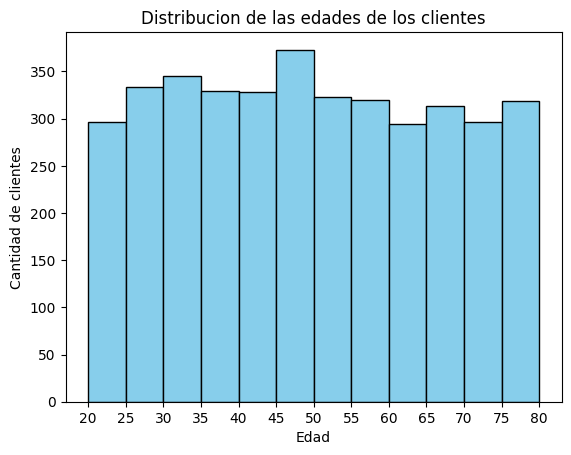

In [78]:
# Histograma para visualizar la edad (age)
counts, bin_edges, _=plt.hist(user_profile['age'], bins=12,range=(20,80), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.title('Distribucion de las edades de los clientes')
plt.show()

💡Insights:
- En general el grafico muestra una distribucion aproximadamente simétrica, no observamos picos que resalten sobre los demas, pero podemos notar que hay una mayoria de clientes de 45 a 50 años y tambien en el rango entre 25 a 35 años por lo que se podria explorar una captacion de clientes a edades mas jovenes.

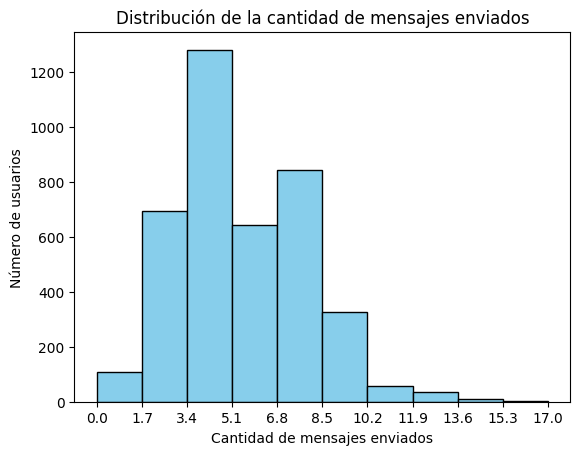

In [79]:
# Histograma para visualizar la cant_mensajes
counts, bin_edges, _=plt.hist(user_profile['cant_mensajes'], bins=10, range=(0,17), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)
plt.xlabel('Cantidad de mensajes enviados')
plt.ylabel('Número de usuarios')
plt.title('Distribución de la cantidad de mensajes enviados')
plt.show()

💡Insights:
- El grafico muestra una distribucion sesgada a la derecha, mostrando la cantidad de mensajes que envia la mayoria de los usuarios es de entre 3 a 5, pero existe un pequeño grupo con uso intensivo. Una razon de uso no muy intensivo se puede deber al uso de otras aplicaciones como WhatsApp

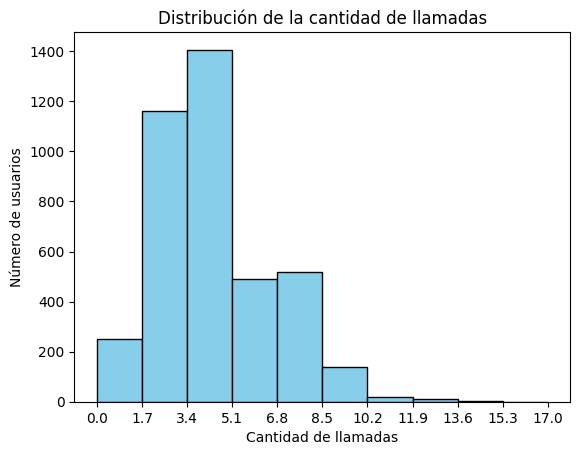

In [80]:
# Histograma para visualizar la cant_llamadas
counts, bin_edges, _=plt.hist(user_profile['cant_llamadas'], bins=10, range=(0,17), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de usuarios')
plt.title('Distribución de la cantidad de llamadas')
plt.show()

💡Insights:
- Se observa una distrubucion similar a la de los mensajes con una distribucion sesgada a la derecha que indica que la mayoria de los clientes tiene un uso bajo o moderado del servicio. pero existe un grupo de clientes que hace un uso intensivo el cual puede representar una oportunidad estratégica de monetizacion

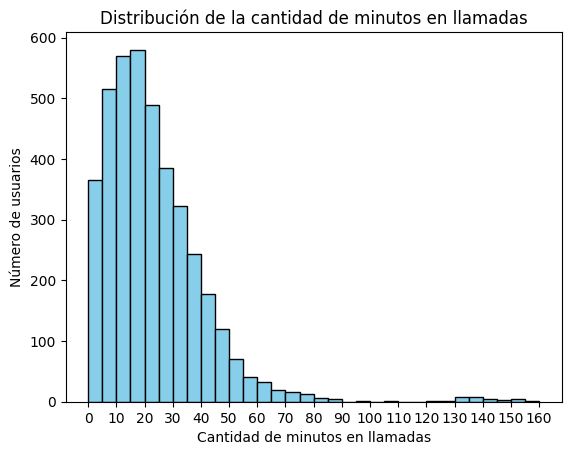

In [81]:
# Histograma para visualizar la cant_minutos_llamada
counts, bin_edges, _=plt.hist(user_profile['cant_minutos_llamada'], bins=32, range=(0,160), color='skyblue', edgecolor='black')
plt.xticks(bin_edges[: :2])
plt.xlabel('Cantidad de minutos en llamadas')
plt.ylabel('Número de usuarios')
plt.title('Distribución de la cantidad de minutos en llamadas')
plt.show()

💡Insights:
- La distribución presenta una marcada asimetría positiva, con mayor concentracion en 5-20 min de llamadas, y con un sesgo hacia consumos mas elevados lo cual podria representar a los clientes que mayores ingresos generan. Lo que abre a oportunidades para diseñar planes diferenciados y estrategias de fidelizacion.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

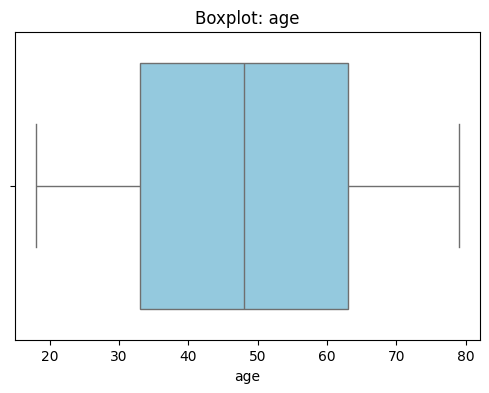

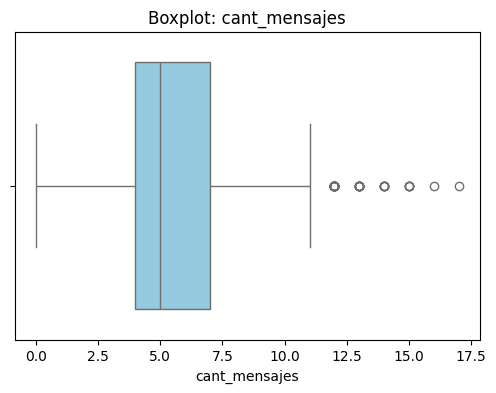

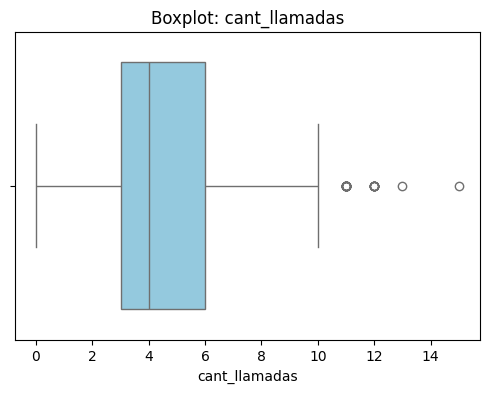

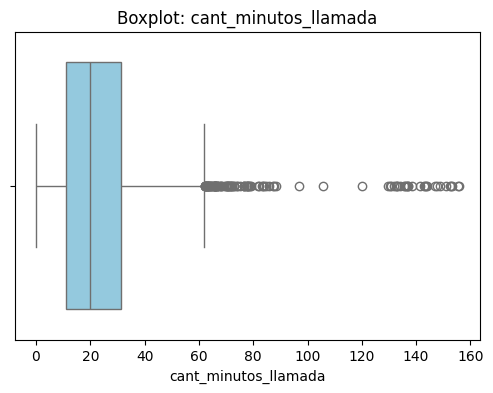

In [82]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=user_profile[col], color='skyblue')

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

💡Insights:
- `Age:` Se observa una estructura relativamente simetrica con la mediana centrada, no se observan valores fuera de los limites, sugiriendo clientes etariamente estables y sin concentraciones extremas.
- `cant_mensajes:` La estructura presenta una asimetria positiva y varios outliers hacia la derecha que marca la existencia de un segmento reducido de usuarios intensivos, el cual podria ser util para campañas dirigidas a usuarios de alto valor.
- `cant_llamadas:` El boxplot muestra asimetria hacia la derecha, y unos pocos valores atípicos en el extremo superior por posibles por posible segmento de alto consumo, el cual podria analizarse como grupo de alto valor.
- `cant_minutos_llamada:` La distribucion muestra una fuerte concentracion en los valores mas bajos, lo que indica que la mayoria de usuarios realiza llamadas de menor duracion, sin embargo, se observa una cantidad significativa de valores atípicos en el extremo superior, representando un segmento de usuarios con consumo intensivo. Este grupo podría concentrar una proporción relevante del ingreso y constituye una oportunidad estratégica para segmentación y programas de fidelización orientados a maximizar el valor por cliente.

In [83]:
# Calcular límites con el método IQR
outlier = {}
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    print('')
    print(f"📊 Analizando columna: {col}")
    print("-" * 50)
    print('Primer Cuartil', Q1)
    Q2 = user_profile[col].quantile(0.50)
    print('Segundo Cuartil', Q2)
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer Cuartil', Q3)
    IQR = Q3 - Q1
    print('IQR', IQR)
    limite_superior = (Q3 + 1.5 * IQR)
    print('límite superior', limite_superior)
    outlier[col] = user_profile[user_profile[col] > limite_superior]
    porcentaje = (len(outlier[col]) / len(user_profile)) * 100
    print(f"Usuarios con outliers: {len(outlier[col])} ({porcentaje:.2f}%)")
    if len(outlier[col]) > 0:
        print()
        print('características de usuarios con outliers en:', col)
        print(outlier[col][col].describe())


📊 Analizando columna: age
--------------------------------------------------
Primer Cuartil 33.0
Segundo Cuartil 48.0
Tercer Cuartil 63.0
IQR 30.0
límite superior 108.0
Usuarios con outliers: 0 (0.00%)

📊 Analizando columna: cant_mensajes
--------------------------------------------------
Primer Cuartil 4.0
Segundo Cuartil 5.0
Tercer Cuartil 7.0
IQR 3.0
límite superior 11.5
Usuarios con outliers: 46 (1.15%)

características de usuarios con outliers en: cant_mensajes
count    46.000000
mean     12.891304
std       1.251280
min      12.000000
25%      12.000000
50%      12.000000
75%      13.000000
max      17.000000
Name: cant_mensajes, dtype: float64

📊 Analizando columna: cant_llamadas
--------------------------------------------------
Primer Cuartil 3.0
Segundo Cuartil 4.0
Tercer Cuartil 6.0
IQR 3.0
límite superior 10.5
Usuarios con outliers: 30 (0.75%)

características de usuarios con outliers en: cant_llamadas
count    30.000000
mean     11.466667
std       0.860366
min      11.00

In [84]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- `cant_mensajes:` Se mantienen los outliers ya que no son valores imposibles ni datos erroneos, ocupan el 1,5% lo que no distorsiona las estadisticas significativamente.
- `cant_llamadas:` Se mantienen los outliers al igual que con mensajes ya que no son cantidades imposibles y en este caso el porcentaje de outliers es de 0,75% por lo que tampoco afecta a estudios estadisticos
- `cant_minutos_llamada:` En este caso no conviene mantener los outliers ya que son numeros muy elevados y ocupan casi un 3% de los datos, conviene hacer una winsorizacion reemplazándolos por el limite superior pero si tener en cuenta ese grupo para posibles campañas como de fidelizacion. La windsorizacion se realizará para que estos datos no afecten a calculos posteriores

In [85]:
# Windsorizacion de datos en cant_minutos_llamada

limite_superior = user_profile['cant_minutos_llamada'].quantile(0.97)
user_profile['cant_minutos_llamada_winsor'] = np.clip(user_profile['cant_minutos_llamada'],
                                    a_min=None,
                                    a_max=limite_superior)
print("ANTES de winsorización:")
print(user_profile['cant_minutos_llamada'].describe())
print("\nDESPUÉS de winsorización:")
print(user_profile['cant_minutos_llamada_winsor'].describe())

ANTES de winsorización:
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

DESPUÉS de winsorización:
count    3999.000000
mean       22.494357
std        14.689637
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max        60.496600
Name: cant_minutos_llamada_winsor, dtype: float64


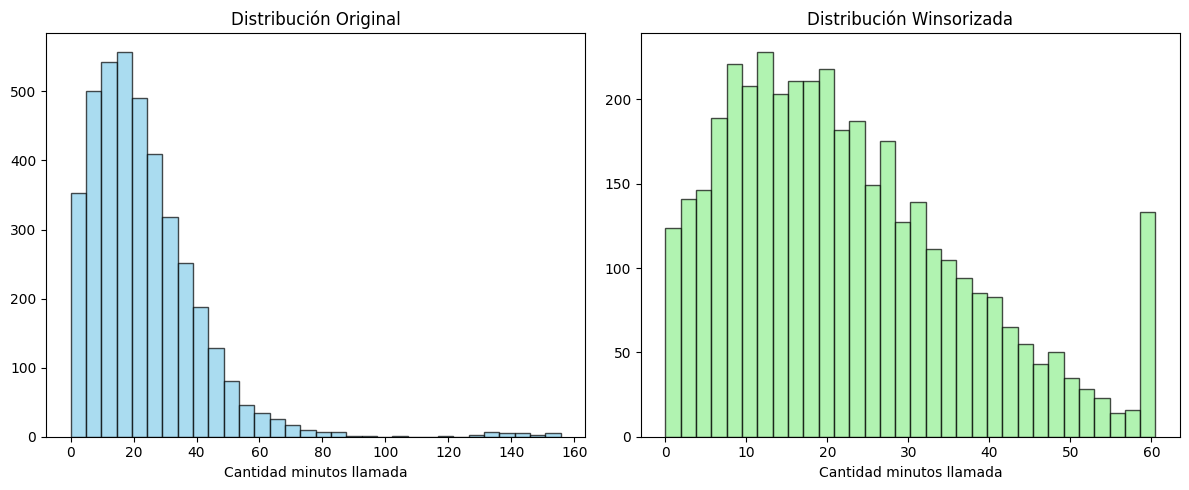

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
axes[0].hist(user_profile['cant_minutos_llamada'], bins=32, alpha=0.7, color='skyblue', edgecolor= 'black')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel('Cantidad minutos llamada')

# Winsorizada
axes[1].hist(user_profile['cant_minutos_llamada_winsor'], bins=32, alpha=0.7, color='lightgreen', edgecolor= 'black')
axes[1].set_title('Distribución Winsorizada')
axes[1].set_xlabel('Cantidad minutos llamada')

plt.tight_layout()
plt.show()

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

In [87]:
# Crear columna grupo_uso
user_profile['grupo_uso']= np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] <5), 'Bajo Uso',
        np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] <10), 'Uso Medio', 'Alto Uso')
)

In [88]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_minutos_llamada_winsor,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,23.70,Uso Medio
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,33.18,Alto Uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,10.74,Uso Medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,8.99,Alto Uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

In [89]:
# Crear columna grupo_edad
user_profile['grupo_edad']= np.where(
    (user_profile['age'] < 30), 'Joven',
        np.where((user_profile['age'] < 60), 'Adulto', 'Adulto Mayor')
)

In [90]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_minutos_llamada_winsor,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

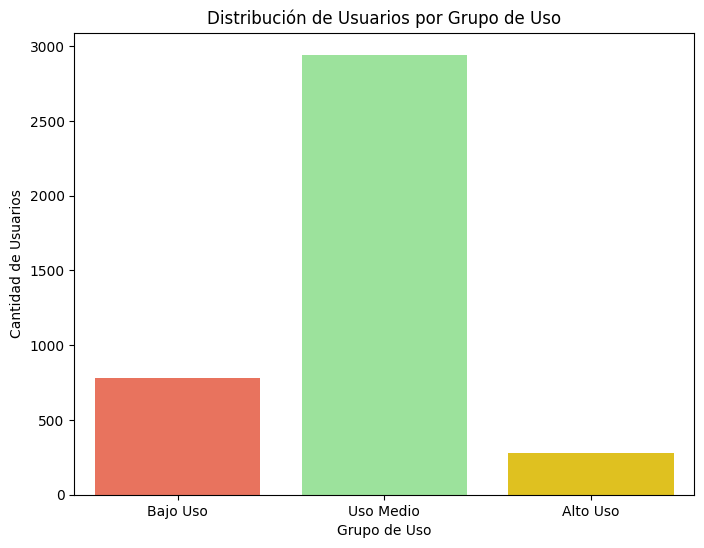

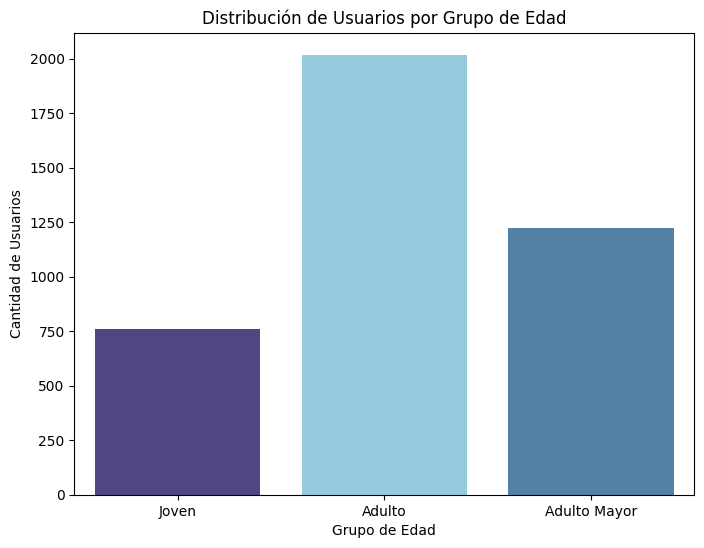

In [92]:
# Visualización de los segmentos por uso
orden_uso = ['Bajo Uso', 'Uso Medio', 'Alto Uso']
colores_uso = ['lightgreen', 'gold', 'tomato']

plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette=colores_uso, hue='grupo_uso', legend=False)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Visualización de los segmentos por edad
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
colores_edad = ['skyblue', 'steelblue', 'darkslateblue']

plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette=colores_edad, hue='grupo_edad', legend=False)
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

plt.show()

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- El análisis inicial reveló inconsistencias que requirieron limpieza para no sesgar los resultados:

- Se realizó una estandarización de los datos, convirtiendo los tipos a los correctos

- Inconsistencias en la columna `city`: Tenía un 11.7% de datos faltantes (469 filas) y la presencia del carácter "?" como sentinel, lo que se resolvió con reeplazo a nulos.

- Inconsistencias en `age`: se encontraron sentinels ''-999' que se reemplazaron por la mediana.

- Se detectó que los nulos en `duration` (55.2%) y en `length` (44.7%) se deben a la relación de estos valores con el `type` de dato: si es mensaje, la duración es nula y si es llamada, la longitud de texto es nula.

- Se ajustaron estadísticamente los valores extremos (Winsorización) en `cant_minutos_llamada` para asegurar que el promedio de consumo no se viera inflado por comportamientos atípicos.

🔍 **Segmentos por Edad**
El perfil demográfico de ConnectaTel muestra una distribución interesante:

- Jóvenes y Adultos: La edad promedio de los usuarios ronda los 30-50 años, con una presencia notable en ciudades principales como Bogotá (la ciudad con mayor frecuencia).

- Comportamiento: Se observa que el plan Básico es el más adoptado por la mayoría de los rangos de edad, representando a 2,595 usuarios del total de 4,000 analizados.

📊 **Segmentos por Nivel de Uso**
- Se identificaron dos perfiles de consumo claros basados en el tipo de servicio:

- Usuarios de Mensajería (Text): Es el servicio más frecuente con 22,092 registros de uso, superando a las llamadas de voz.

- Usuarios de Voz (Call): Representan una menor frecuencia pero generan mayor variabilidad en los datos de duración.

- Outliers (Uso Extremo): Se detectaron valores atípicos significativos, como llamadas de hasta 120 minutos y mensajes con longitudes de 1,490 caracteres.


➡️ Esto sugiere que... Valor para el negocio: Los clientes del plan Premium son los más valiosos económicamente, pero el volumen masivo de datos está en el plan Básico, donde existe una oportunidad de upselling (migración de plan) si detectamos quiénes exceden constantemente sus límites.

Implicación de Outliers: Los patrones de uso extremo (llamadas de 2 horas o mensajes larguísimos) sugieren que un pequeño grupo de usuarios está utilizando el servicio para fines comerciales o profesionales, lo que podría afectar la estabilidad de la red o los márgenes de los planes ilimitados.


💡 **Recomendaciones**
- Optimización de Planes: Crear un plan intermedio. Dado que el salto del Básico al Premium puede ser grande, un plan "Básico Plus" enfocado en más SMS podría captar al segmento que más utiliza el servicio de texto.

- Estrategia de Retención: Investigar el 11.7% de clientes con ciudad desconocida; la falta de datos geográficos puede estar ocultando problemas de cobertura regional que deriven en churn (cancelación).

- Control de Consumo: Implementar alertas de consumo para los "outliers". Si un usuario del plan Básico alcanza duraciones de llamadas extremas, ofrecerle promociones inmediatas para migrar a un plan con más minutos.